# ARENA Solar Report

**Author:** Arthur D'avila de Paiva

**Date:** June 2026

## Executive summary

---

* This report analyses solar energy adoption pattern across the Greater Melbourne on behalf of the Australian Renewable Energy Agency (ARENA), combining federal solar installations and capacity data with Melbourne property sales records, Australian Bureau of Statistics Census data and geographic postcode information across 225 Melbourne postcodes.

* Data was cleaned, merged and analysed using Python, with clustering, statistical testing, and geospatial mapping applied to identify distinct adoption patterns and their underlying drivers.

* The key findings are:
    * Solar uptake increases dramatically with distance from the CBD, fringe suburbs install solat at ten times the rate of inner-city postcodes.
    * Apartments and rentals are the prinary barriers for solar installation.
    * The proportion of detached houses is the strongest structural predictor, while household income showed no significant correlation.

* The main recommendations for ARENA are to invest in Victoria's Solar for Apartment program, address the landlord-tenant split incentive through targeted rental rebates and focus outreach on moderate-adoption middle suburbs.

## Introduction

---

### Objectives

* This analysis was undertaken from the perspective of a data analyst working for the Australian Renewable Energy Agency (ARENA), with the purpose of informing future solar energy investment decisions, program design, and policy recommendations across the Greater Melbourne.

### Approach

* The analysis followed a structured quantitative pipeline, moving from raw datasets to data normalisation, visualisation, application of clustering techniques and results interpretation.

## Methodology

---

### Data sources

**SGU Solar Installations and Capacity Datasets**

* Identically structured datasets published by the Clean Energy Regulator, recording the number of small-scale solar PV installations registered under the SRES and the total rated power output in kilowatts (kW) of installed systems by postcode monthly.
* Published under Creative Commons Attribution 3.0 Australia (CC BY 3.0 AU). Free to use, share and adapt with attribution.

**Melbourne Housing Market Dataset**

* It includes address, property types, suburbs, sale methods and other information about properties in Melbourne, covering the period from January 2016 to October 2018. Scraped from publicly available results posted on Domain.com.au website, cleaned by Anthony Pino and posted on Kaggle.
* Published under the Creative Commons Attribuition-NonCommerical-ShareAlike 4.0 license (CC BY-NC-SA 4.0). As ARENA is a Commonwealth government agency conducting a policy research, use falls within scope.

**ABS 2021 Census - Victoria DataPack**

* Census DataPacks contain comprehensive data about people, families and dwellings for all Census geographie. Four tables were extracted from Victoria Postal Areas DataPack:

| File | Contents                                           |
|------|----------------------------------------------------|
| G01  | Total population per postcode                      |
| G02  | Median income, rent, mortgage repayments           |
| G38  | Dwelling type composition for mortgaged properties |
| G40  | Total renting households and public housing counts |

* Published under Creative Commons Attribution 4.0 International (CC BY 4.0). Free to use with attribution.

**Australian Postcodes**

* A community-sourced comprehensive database of Australian postcodes with geolocation data managed by Matthew Proctor. It provides postcode, locality name, state, latitude and longitude, and ABS statistical area classification.
* As an open-source dataset, it is free to use without restriction or access limitations.

### Analytical tools

#### Pandas

Pandas was the primary data manipulation library used throughout the analysis. It was used to load all datasets, perform format transformations, parse and align datetime column, and group and merge data

#### Matplotlib

Matplotlib provided the underlying figure and axed infrastructure for all visualisations. It was used to construct the subplot layouts, set figures sizes, apply titles and axis labels, and render the final charts.

#### Seaborn

Seaborn was used for all chart rendering, for the time-series comparison and was applied globally to standardise the visual style across all charts.

#### Scikit-Learn

Used for the clustering and dimensionality reduction components of the analysis.

#### SciPy

Used for all statistical significance testing

### Data preparation

#### Collection Methods

All datasets were downloaded manually from their respective sources and stored locally in a "data_files/" directory. The ABS Census DataPack was downloaded as a ZIP archive from the web portal, with the relevant tables CSV files extracted from the Postal Areas subfolder. Solar and housing files were provided directly for this assessment.

#### Data Cleaning

The ABS DataPack ZIP contains multiple table files across multiple geographic levels. Only files related to the poplation, income, dwelling structure and tenure were used. A reusable functions was written to handle each file identically, stripping prefixes and filtering to Melbourne postcodes.

The "Melboune_House_Prices_Less.csv" file was used due to less missing data in comparison to similar file with more information.

Postcodes with an adoption rate greater than 1.5 installations per property were excluded from all plotting and clustering steps as non-residential outliers. Similarly, postcodes with average system size exceeding 15kW were excluded from plots.

#### Data Transformation

Both Solar CSV files were delivered in wide format, being unsuitable for time-series filtering and aggregation. Both files were melted to long format with the postcode column as the identifier and each monthly column becoming a row instead.

Rather than using all monthly data, records were filtered to the period covered by the housing data (up to October 2018) before aggregation

All processed datasets were joined sequentially based on a Postcode Key. An inner join was used between the solar and housing summaries to define the analysis of 225 Melbourne postcodes with both data. Left joins were used for the census and postcode lookup tables to preserve all postcodes even where census coverage was incomplete.

## Analysis and Findings

---

### Data Normalisation

In [1]:
import pandas as pd
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

# Solar installations
solar_installs_raw = pd.read_csv("data_files/sgu-solar-installations-2011-to-present.csv")
solar_capacity_raw = pd.read_csv("data_files/sgu-solar-capacity-2011-to-present.csv")

# Filter to Melbourne postcodes (3000–3999)
solar_installs_mel = solar_installs_raw[solar_installs_raw["Small Unit Installation Postcode"].between(3000, 3999)].copy()
solar_capacity_mel = solar_capacity_raw[solar_capacity_raw["Small Unit Installation Postcode"].between(3000, 3999)].copy()

# Housing
housing_raw = pd.read_csv("data_files/MELBOURNE_HOUSE_PRICES_LESS.csv")
housing_raw["Date"] = pd.to_datetime(housing_raw["Date"], dayfirst=True)
# print(f"  Housing records: {len(housing_raw)} | Date range: {housing_raw['Date'].min().date()} → {housing_raw['Date'].max().date()}")

# Postcode lookup
postcodes_raw = pd.read_csv("data_files/australian_postcodes.csv")
postcode_lookup = (postcodes_raw[(postcodes_raw["state"] == "VIC") & (postcodes_raw["type"] == "Delivery Area") & (postcodes_raw["postcode"].between(3000, 3999))].drop_duplicates(subset="postcode")[["postcode", "locality", "lgaregion", "lat", "long"]].reset_index(drop=True))
# print(f"  Postcode lookup — unique Melbourne postcodes: {len(postcode_lookup)}")

# Census files
def load_census(path, cols):
    df = pd.read_csv(path, usecols=cols)
    df["Postcode"] = df["POA_CODE_2021"].str.replace("POA", "").astype(int)
    df = df[df["Postcode"].between(3000, 3999)].drop(columns="POA_CODE_2021")
    return df.reset_index(drop=True)

census_g01 = load_census("data_files/2021Census_G01_VIC_POA.csv", ["POA_CODE_2021", "Tot_P_P"])
census_g02 = load_census("data_files/2021Census_G02_VIC_POA.csv", ["POA_CODE_2021", "Median_age_persons", "Median_mortgage_repay_monthly","Median_tot_prsnl_inc_weekly", "Median_rent_weekly","Median_tot_hhd_inc_weekly", "Average_household_size"])
census_g38 = load_census("data_files/2021Census_G38_VIC_POA.csv", ["POA_CODE_2021", "Tot_DS_Separate_hse", "Tot_DS_sd_row_tce_hse_thse","Tot_DS_Flat_apartment", "Tot_DS_Other_dwg", "Tot_Tot"])
census_g38 = census_g38.rename(columns={"Tot_Tot": "Total_Mortgaged_Dwellings"})
census_g40 = load_census("data_files/2021Census_G40_VIC_POA.csv", ["POA_CODE_2021", "Tot_LT_Ste_ter_hsg_auth", "Tot_LT_com_hou_pro", "Tot_Tot"])
census_g40 = census_g40.rename(columns={"Tot_Tot": "Total_Renting_Dwellings"})
# print(f"  Census G01: {len(census_g01)} | G02: {len(census_g02)} | G38: {len(census_g38)} | G40: {len(census_g40)}")

# Solar: Formating date type and time to match housing data
def process_solar(df, value_col_name):
    postcode_col = "Small Unit Installation Postcode"
    month_cols = [c for c in df.columns if c != postcode_col]
    long = df.melt(id_vars=postcode_col, value_vars=month_cols, var_name="Month", value_name=value_col_name)
    long["Date"] = pd.to_datetime(long["Month"].str.split(" - ").str[0], format="%b %Y")

    # Filter to records up to and including the housing data period (Oct 2018)
    long = long[long["Date"] <= "2018-10-31"]

    return long.groupby(postcode_col)[value_col_name].sum().reset_index().rename(columns={postcode_col: "Postcode"})

solar_summary = process_solar(solar_installs_mel, "Total_Installations")
capacity_summary = process_solar(solar_capacity_mel, "Total_Capacity_kW")
solar_combined = pd.merge(solar_summary, capacity_summary, on="Postcode", how="inner")
# print(f"Solar combined — postcodes: {len(solar_combined)}")
# print(f"Total installations across Melbourne: {solar_combined['Total_Installations'].sum():,.0f}")
# print(f"Total capacity across Melbourne: {solar_combined['Total_Capacity_kW'].sum():,.1f} kW")

# Housing: aggregate to postcode level
housing_summary = (
housing_raw.groupby("Postcode").agg(
    Median_Sale_Price=("Price", "median"),
    Mean_Sale_Price=("Price", "mean"),
    Total_Sales=("Price", "count"),
    Pct_Houses=("Type", lambda x: (x == "h").mean() * 100),
    Pct_Units=("Type", lambda x: (x == "u").mean() * 100),
    Pct_Townhouses=("Type", lambda x: (x == "t").mean() * 100),
    Median_Rooms=("Rooms", "median"),
    Median_Distance=("Distance", "median"),
    Propertycount=("Propertycount", "median"),
    Regionname=("Regionname", lambda x: x.mode()[0]),
    CouncilArea=("CouncilArea", lambda x: x.mode()[0]),
).reset_index())
# print(f"  Housing summary — postcodes: {len(housing_summary)}")

# Census: Merging all four tables into one
census = census_g01.merge(census_g02, on="Postcode", how="outer")
census = census.merge(census_g38, on="Postcode", how="outer")
census = census.merge(census_g40, on="Postcode", how="outer")
# print(f"  Census combined — postcodes: {len(census)}")

# Creating one data frame with all relevant data based on postcode
master = (
    solar_combined
    .merge(housing_summary, on="Postcode", how="inner")
    .merge(census, on="Postcode", how="left")
    .merge(postcode_lookup, left_on="Postcode", right_on="postcode", how="left")
    .drop(columns="postcode")   # duplicate of Postcode
)

# print(f"  Master DataFrame shape: {master.shape}")
# print(f"  Postcodes in master: {master['Postcode'].nunique()}")

# Solar adoption rate
master["Adoption_Rate"] = (master["Total_Installations"] / master["Propertycount"])

# Average kW per installation
master["Avg_System_kW"] = master.apply(lambda r: r["Total_Capacity_kW"] / r["Total_Installations"]if r["Total_Installations"] > 0 else 0,axis=1)

# Dwelling type proportions from Census G38
mortgaged_total = master["Total_Mortgaged_Dwellings"].replace(0, pd.NA)
master["Pct_Separate_House"] = (master["Tot_DS_Separate_hse"] / mortgaged_total * 100)
master["Pct_Apartment"] = (master["Tot_DS_Flat_apartment"] / mortgaged_total * 100)
master["Pct_Townhouse"] = (master["Tot_DS_sd_row_tce_hse_thse"] / mortgaged_total * 100)

# Rental proportion — renters vs total tracked dwellings
tracked_dwellings = (master["Total_Mortgaged_Dwellings"].fillna(0) + master["Total_Renting_Dwellings"].fillna(0)).replace(0, pd.NA)
master["Pct_Renting"] = (master["Total_Renting_Dwellings"] / tracked_dwellings * 100)

# Public housing proportion
master["Pct_Public_Housing"] = ( master["Tot_LT_Ste_ter_hsg_auth"] / master["Total_Renting_Dwellings"].replace(0, pd.NA) * 100)

# Distance band — ring classification from CBD
master["Distance_Band"] = pd.cut(master["Median_Distance"],bins=[0, 10, 20, 35, 100],labels=["Inner (0–10km)", "Middle (10–20km)", "Outer (20–35km)", "Fringe (35km+)"])

# print(f"Adoption Rate — min: {master['Adoption_Rate'].min():.3f} | max: {master['Adoption_Rate'].max():.3f} | mean: {master['Adoption_Rate'].mean():.3f}")
# print(f"Avg System kW — mean: {master['Avg_System_kW'].mean():.2f} kW")
# print(f"Distance bands:\n{master['Distance_Band'].value_counts().sort_index()}")

### Data Visualisation - Geographic Patterns

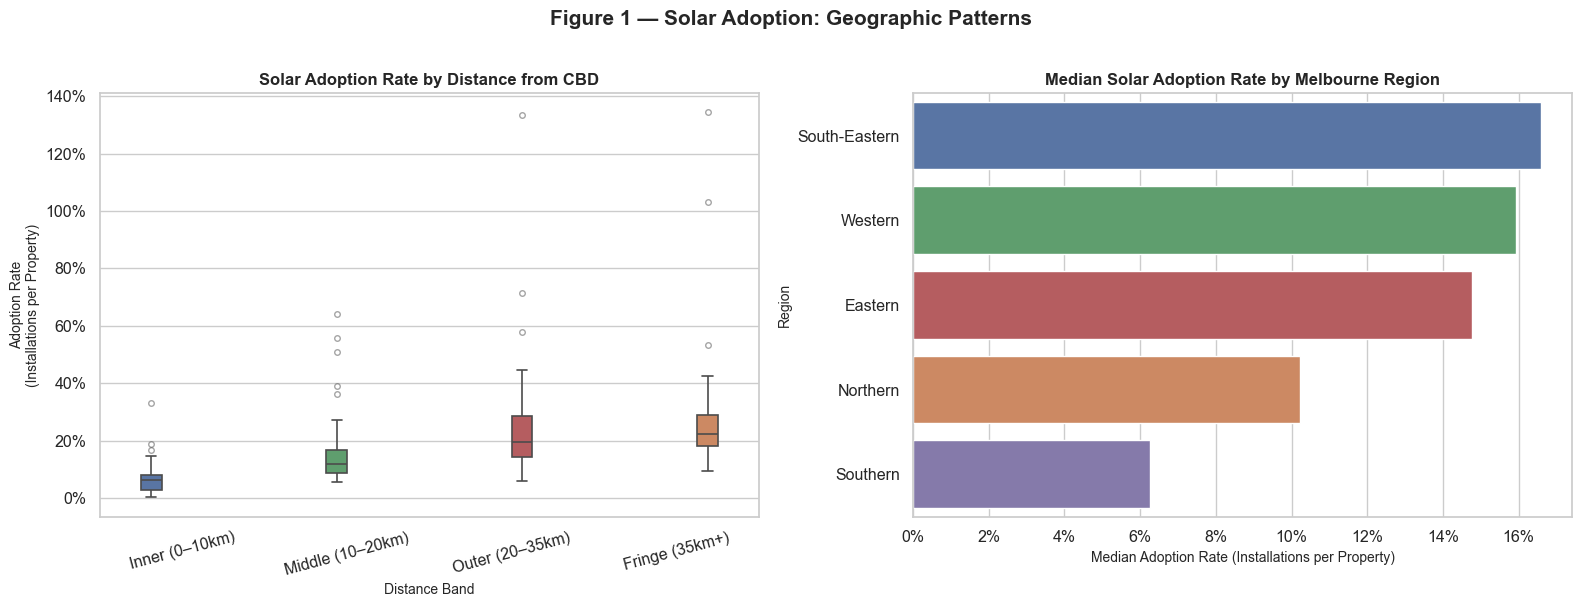

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

# Filtering out CBD outliers and non-metropolitan areas
plot_df = master[master["Adoption_Rate"] <= 1.5].copy()
metro_regions = [r for r in plot_df["Regionname"].unique() if "Metropolitan" in str(r)]
plot_metro = plot_df[plot_df["Regionname"].isin(metro_regions)].copy()

region_labels = {
    "Eastern Metropolitan":        "Eastern",
    "Northern Metropolitan":       "Northern",
    "South-Eastern Metropolitan":  "South-Eastern",
    "Southern Metropolitan":       "Southern",
    "Western Metropolitan":        "Western",
}
plot_metro["Region"] = plot_metro["Regionname"].map(region_labels)

band_order  = ["Inner (0–10km)", "Middle (10–20km)", "Outer (20–35km)", "Fringe (35km+)"]
band_palette = {
    "Inner (0–10km)":   "#4C72B0",
    "Middle (10–20km)": "#55A868",
    "Outer (20–35km)":  "#C44E52",
    "Fringe (35km+)":   "#DD8452",
}

sns.set_theme(style="whitegrid", font_scale=1.05)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle("Figure 1 — Solar Adoption: Geographic Patterns", fontsize=15, fontweight="bold", y=1.01)

# Chart 1: Adoption Rate by Distance Band
band_data = plot_df[plot_df["Distance_Band"].notna()]
sns.boxplot(data=band_data, x="Distance_Band", y="Adoption_Rate", order=band_order, hue="Distance_Band", legend=False, palette=band_palette, width=0.5, linewidth=1.2,              flierprops=dict(marker="o", markersize=4, alpha=0.5), ax=ax1)
ax1.set_title("Solar Adoption Rate by Distance from CBD", fontsize=12, fontweight="bold")
ax1.set_xlabel("Distance Band", fontsize=10)
ax1.set_ylabel("Adoption Rate\n(Installations per Property)", fontsize=10)
ax1.tick_params(axis="x", rotation=15)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Chart 2: Median Adoption Rate by Region
region_summary = (plot_metro.groupby("Region")["Adoption_Rate"].median().reset_index().sort_values("Adoption_Rate", ascending=False))
region_colors = ["#4C72B0", "#55A868", "#C44E52", "#DD8452", "#8172B2"]
sns.barplot(data=region_summary, x="Adoption_Rate", y="Region", hue="Region", legend=False, palette=dict(zip(region_summary["Region"], region_colors[:len(region_summary)           ])), ax=ax2)
ax2.set_title("Median Solar Adoption Rate by Melbourne Region", fontsize=12, fontweight="bold")
ax2.set_xlabel("Median Adoption Rate (Installations per Property)", fontsize=10)
ax2.set_ylabel("Region", fontsize=10)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

fig1.tight_layout()

### Data Visualisation - Property Market Relationship

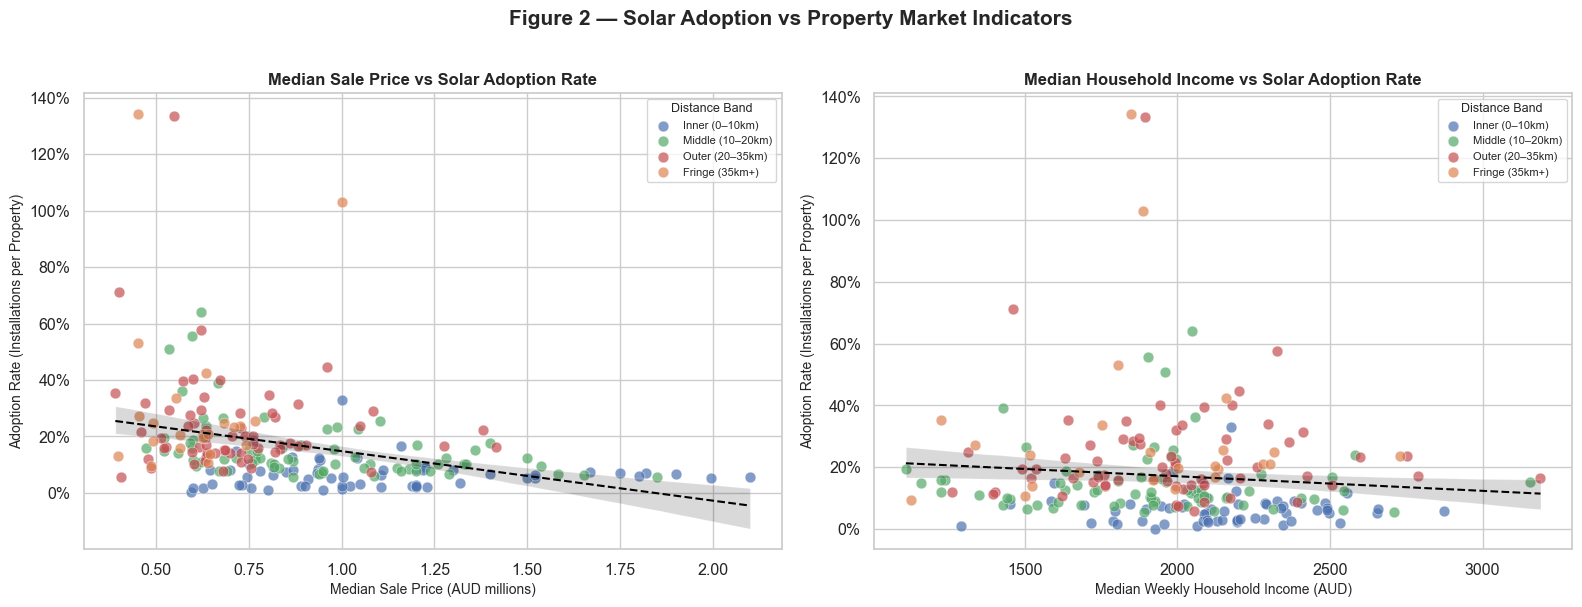

In [3]:
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle("Figure 2 — Solar Adoption vs Property Market Indicators", fontsize=15, fontweight="bold", y=1.01)

scatter_df = plot_df[plot_df["Distance_Band"].notna()].copy()
# Chart 3: Median Sale Price vs Adoption Rate
for band in band_order:
    sub = scatter_df[scatter_df["Distance_Band"] == band]
    ax3.scatter(sub["Median_Sale_Price"] / 1e6, sub["Adoption_Rate"], label=band, color=band_palette[band], alpha=0.7, edgecolors="white", linewidth=0.4, s=60)

# Trend line
valid = scatter_df[["Median_Sale_Price", "Adoption_Rate"]].dropna()
sns.regplot(x=valid["Median_Sale_Price"] / 1e6, y=valid["Adoption_Rate"], scatter=False, ax=ax3, line_kws={"color": "black", "linewidth": 1.5, "linestyle": "--"}, ci=95)
ax3.set_title("Median Sale Price vs Solar Adoption Rate", fontsize=12, fontweight="bold")
ax3.set_xlabel("Median Sale Price (AUD millions)", fontsize=10)
ax3.set_ylabel("Adoption Rate (Installations per Property)", fontsize=10)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax3.legend(title="Distance Band", fontsize=8, title_fontsize=9)

# Chart 4: Household Income vs Adoption Rate
for band in band_order:
    sub = scatter_df[scatter_df["Distance_Band"] == band]
    ax4.scatter(sub["Median_tot_hhd_inc_weekly"], sub["Adoption_Rate"], label=band, color=band_palette[band], alpha=0.7, edgecolors="white", linewidth=0.4, s=60)

sns.regplot(data=scatter_df, x="Median_tot_hhd_inc_weekly", y="Adoption_Rate", scatter=False, ax=ax4, line_kws={"color": "black", "linewidth": 1.5, "linestyle": "--"},
            ci=95)
ax4.set_title("Median Household Income vs Solar Adoption Rate", fontsize=12, fontweight="bold")
ax4.set_xlabel("Median Weekly Household Income (AUD)", fontsize=10)
ax4.set_ylabel("Adoption Rate (Installations per Property)", fontsize=10)
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax4.legend(title="Distance Band", fontsize=8, title_fontsize=9)

fig2.tight_layout()

### Data Visualisation - Socioeconomic and Structural Factors

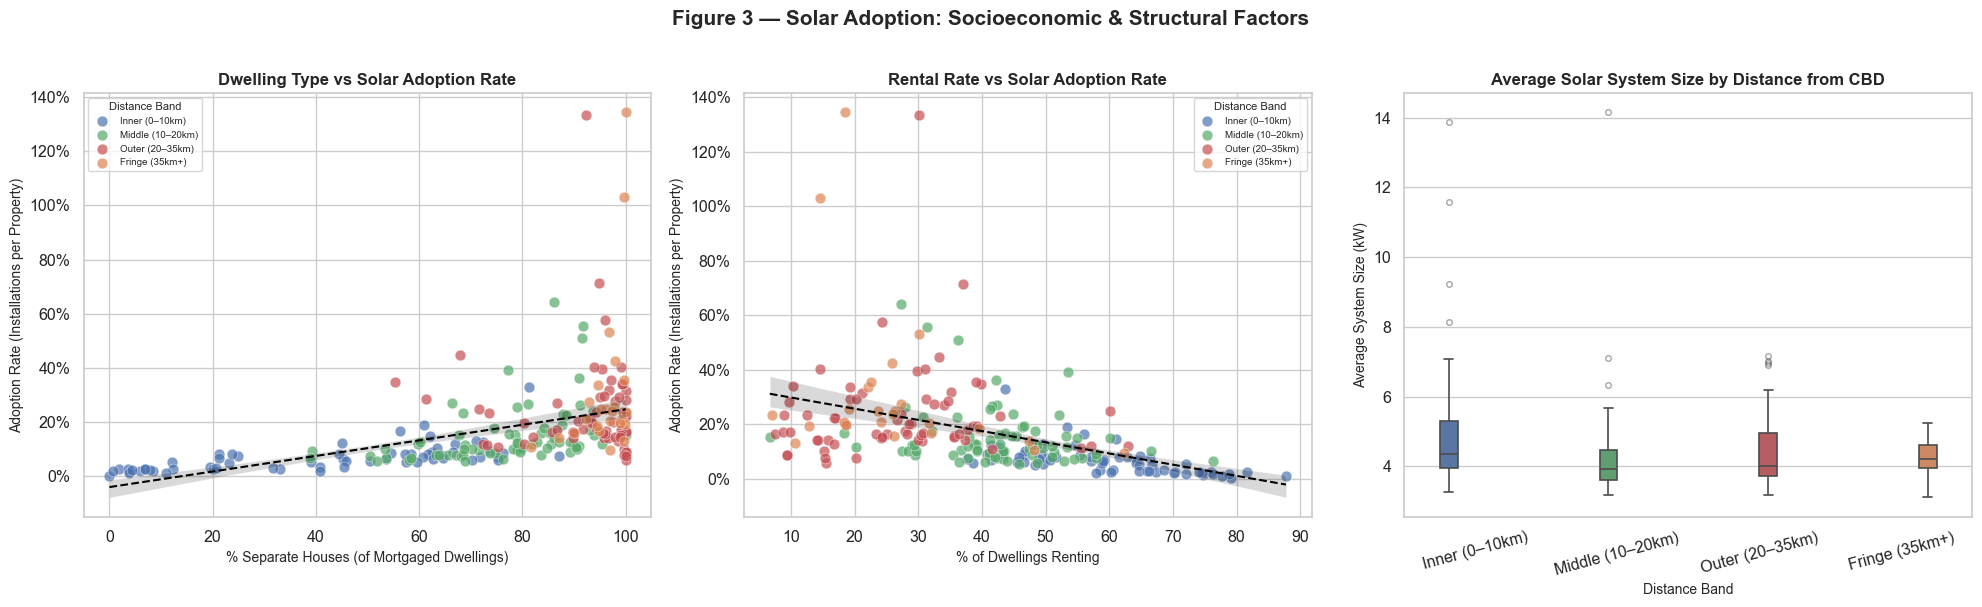

In [4]:
fig3, (ax5, ax6, ax7) = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Figure 3 — Solar Adoption: Socioeconomic & Structural Factors", fontsize=15, fontweight="bold", y=1.01)

# Chart 5: % Separate Houses vs Adoption Rate
scatter_df["Pct_Separate_House"] = scatter_df["Pct_Separate_House"].clip(upper=100)

for band in band_order:
    sub = scatter_df[scatter_df["Distance_Band"] == band]
    ax5.scatter(sub["Pct_Separate_House"], sub["Adoption_Rate"], label=band, color=band_palette[band], alpha=0.7, edgecolors="white", linewidth=0.4, s=60)

sns.regplot(data=scatter_df, x="Pct_Separate_House", y="Adoption_Rate", scatter=False, ax=ax5, line_kws={"color": "black", "linewidth": 1.5, "linestyle": "--"}, ci=95)
ax5.set_title("Dwelling Type vs Solar Adoption Rate", fontsize=12, fontweight="bold")
ax5.set_xlabel("% Separate Houses (of Mortgaged Dwellings)", fontsize=10)
ax5.set_ylabel("Adoption Rate (Installations per Property)", fontsize=10)
ax5.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax5.legend(title="Distance Band", fontsize=7, title_fontsize=8)

# Chart 6: % Renting vs Adoption Rate
for band in band_order:
    sub = scatter_df[scatter_df["Distance_Band"] == band]
    ax6.scatter( sub["Pct_Renting"], sub["Adoption_Rate"], label=band, color=band_palette[band], alpha=0.7, edgecolors="white", linewidth=0.4, s=60)

sns.regplot(data=scatter_df, x="Pct_Renting", y="Adoption_Rate", scatter=False, ax=ax6, line_kws={"color": "black", "linewidth": 1.5, "linestyle": "--"}, ci=95)
ax6.set_title("Rental Rate vs Solar Adoption Rate", fontsize=12, fontweight="bold")
ax6.set_xlabel("% of Dwellings Renting", fontsize=10)
ax6.set_ylabel("Adoption Rate (Installations per Property)", fontsize=10)
ax6.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax6.legend(title="Distance Band", fontsize=7, title_fontsize=8)

# Chart 7: Average System Size by Distance Band
# Cap CBD commercial systems
system_df = scatter_df[scatter_df["Avg_System_kW"] <= 15].copy()

sns.boxplot(data=system_df, x="Distance_Band", y="Avg_System_kW", order=band_order, hue="Distance_Band", legend=False, palette=band_palette, width=0.5, linewidth=1.2,              flierprops=dict(marker="o", markersize=4, alpha=0.5), ax=ax7)
ax7.set_title("Average Solar System Size by Distance from CBD", fontsize=12, fontweight="bold")
ax7.set_xlabel("Distance Band", fontsize=10)
ax7.set_ylabel("Average System Size (kW)", fontsize=10)
ax7.tick_params(axis="x", rotation=15)

fig3.tight_layout()

### Data Analytics - Clustering Evaluation

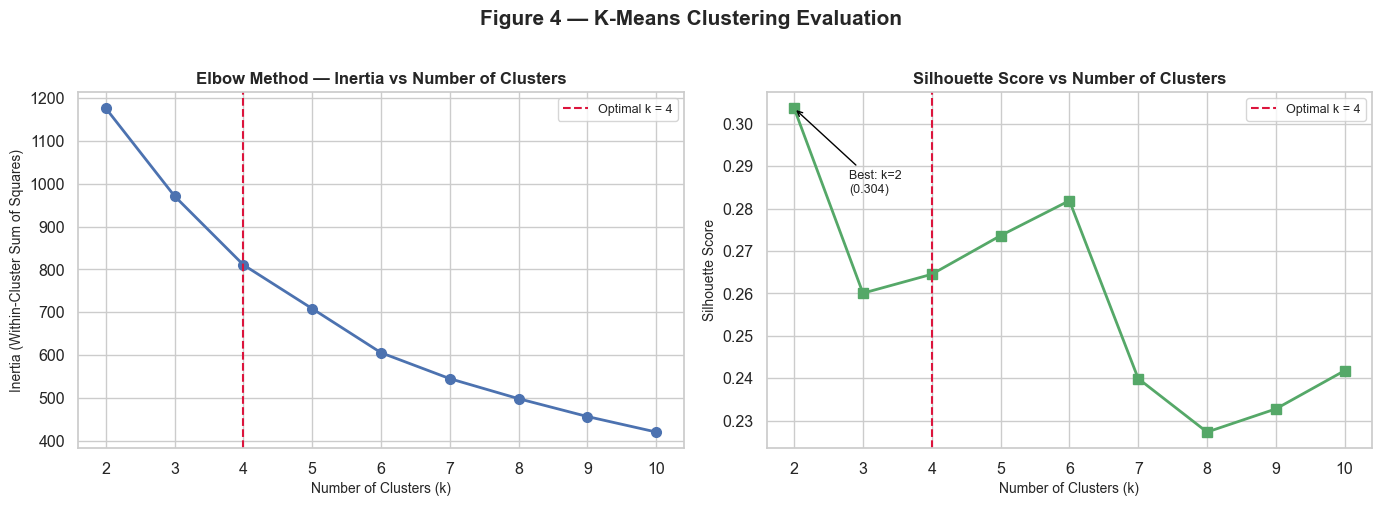

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

raw_features = [
    "Adoption_Rate",
    "Avg_System_kW",
    "Median_tot_hhd_inc_weekly",
    "Pct_Separate_House",
    "Pct_Renting",
    "Median_Distance",
    "Median_Sale_Price",
]
cluster_df = plot_df[raw_features + ["Postcode", "locality", "Regionname", "lat", "long", "Distance_Band"]].dropna().copy()

# Solar Potential Score
# Each component is min-max normalised to [0,1] before combining so no single variable dominates due to scale differences.
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

cluster_df["Solar_Potential_Score"] = (
    minmax(cluster_df["Pct_Separate_House"]) * 0.4 +   # dwelling type — strongest driver
    minmax(cluster_df["Median_tot_hhd_inc_weekly"]) * 0.35 +  # income — financial capacity
    (1 - minmax(cluster_df["Pct_Renting"])) * 0.25     # low renting = higher ownership
)

# Standardising features for clustering & PCA
features_for_clustering = [
    "Adoption_Rate",
    "Avg_System_kW",
    "Median_tot_hhd_inc_weekly",
    "Pct_Separate_House",
    "Pct_Renting",
    "Median_Distance",
    "Median_Sale_Price",
    "Solar_Potential_Score",
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features_for_clustering])
sns.set_theme(style="whitegrid", font_scale=1.05)

k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig4, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle("Figure 4 — K-Means Clustering Evaluation", fontsize=15, fontweight="bold", y=1.01)

# Elbow curve
ax_elbow.plot(list(k_range), inertias, marker="o", color="#4C72B0", linewidth=2, markersize=7)
ax_elbow.set_title("Elbow Method — Inertia vs Number of Clusters", fontsize=12, fontweight="bold")
ax_elbow.set_xlabel("Number of Clusters (k)", fontsize=10)
ax_elbow.set_ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=10)
optimal_k = 4
ax_elbow.axvline(x=optimal_k, color="crimson", linestyle="--", linewidth=1.5, label=f"Optimal k = {optimal_k}")
ax_elbow.legend(fontsize=9)

# Silhouette scores
ax_sil.plot(list(k_range), sil_scores, marker="s", color="#55A868", linewidth=2, markersize=7)
ax_sil.set_title("Silhouette Score vs Number of Clusters", fontsize=12, fontweight="bold")
ax_sil.set_xlabel("Number of Clusters (k)", fontsize=10)
ax_sil.set_ylabel("Silhouette Score", fontsize=10)
ax_sil.axvline(x=optimal_k, color="crimson", linestyle="--", linewidth=1.5, label=f"Optimal k = {optimal_k}")

# Annotate best silhouette
best_k_idx = sil_scores.index(max(sil_scores))
best_k_val = list(k_range)[best_k_idx]
ax_sil.annotate(f"Best: k={best_k_val}\n({max(sil_scores):.3f})", xy=(best_k_val, max(sil_scores)), xytext=(best_k_val + 0.8, max(sil_scores) - 0.02), arrowprops=dict                  (arrowstyle="->", color="black"), fontsize=9)
ax_sil.legend(fontsize=9)

fig4.tight_layout()

### Data Analytics - PCA and Cluster Profiles

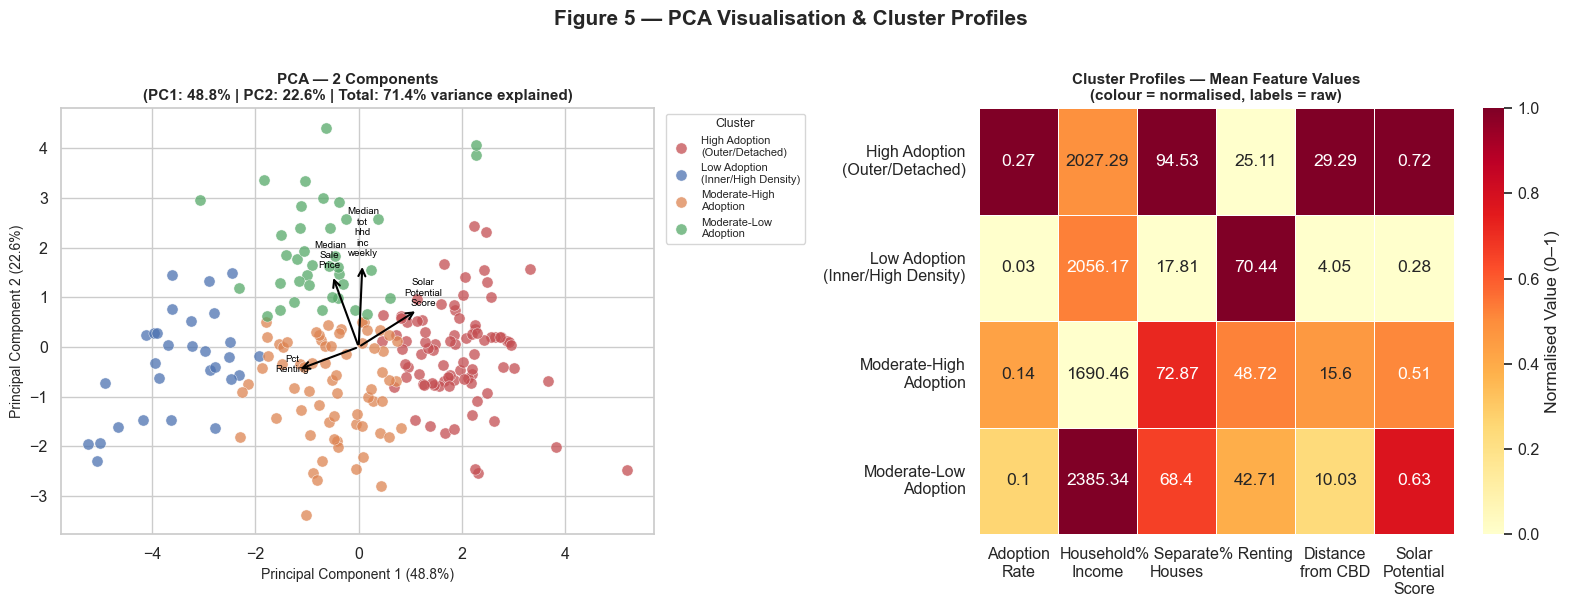

In [6]:
# Final K-Means with optimal k
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_df["Cluster"] = km_final.fit_predict(X_scaled)

# PCA: reduce to 2 components for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cluster_df["PC1"] = X_pca[:, 0]
cluster_df["PC2"] = X_pca[:, 1]

var_explained = pca.explained_variance_ratio_ * 100

# Cluster labels based on profiles
cluster_names = {}
cluster_summary = cluster_df.groupby("Cluster")[["Adoption_Rate", "Median_tot_hhd_inc_weekly", "Pct_Separate_House", "Pct_Renting", "Median_Distance",                                      "Solar_Potential_Score"]].mean().round(3)
# print("  Cluster profiles:\n", cluster_summary.to_string())

adoption_rank = cluster_summary["Adoption_Rate"].rank().astype(int)
name_map = {1: "Low Adoption\n(Inner/High Density)",
            2: "Moderate-Low\nAdoption",
            3: "Moderate-High\nAdoption",
            4: "High Adoption\n(Outer/Detached)"}
cluster_df["Cluster_Label"] = cluster_df["Cluster"].map({c: name_map[adoption_rank[c]] for c in range(optimal_k)})
cluster_palette = {
    "Low Adoption\n(Inner/High Density)": "#4C72B0",
    "Moderate-Low\nAdoption":             "#55A868",
    "Moderate-High\nAdoption":            "#DD8452",
    "High Adoption\n(Outer/Detached)":    "#C44E52",
}

fig5, (ax_pca, ax_profile) = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle("Figure 5 — PCA Visualisation & Cluster Profiles", fontsize=15, fontweight="bold", y=1.01)

for label, grp in cluster_df.groupby("Cluster_Label"):
    ax_pca.scatter(grp["PC1"], grp["PC2"], label=label, color=cluster_palette.get(label, "grey"), alpha=0.75, edgecolors="white", linewidth=0.4, s=65)

ax_pca.set_title(f"PCA — 2 Components\n"
    f"(PC1: {var_explained[0]:.1f}% | PC2: {var_explained[1]:.1f}% | " f"Total: {sum(var_explained):.1f}% variance explained)", fontsize=11, fontweight="bold")
ax_pca.set_xlabel(f"Principal Component 1 ({var_explained[0]:.1f}%)", fontsize=10)
ax_pca.set_ylabel(f"Principal Component 2 ({var_explained[1]:.1f}%)", fontsize=10)
ax_pca.legend(title="Cluster", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")

# PCA Top 4 most influential features
loadings = pd.DataFrame(pca.components_.T, index=features_for_clustering, columns=["PC1", "PC2"])
top_features = loadings.abs().sum(axis=1).nlargest(4).index
scale = 2.5
for feat in top_features:
    ax_pca.annotate("", xy=(loadings.loc[feat, "PC1"] * scale, loadings.loc[feat, "PC2"] * scale), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    ax_pca.text(loadings.loc[feat, "PC1"] * scale * 1.1, loadings.loc[feat, "PC2"] * scale * 1.1, feat.replace("_", "\n"), fontsize=7, ha="center", color="black")

# Cluster profile heatmap
profile_plot = cluster_summary[["Adoption_Rate", "Median_tot_hhd_inc_weekly", "Pct_Separate_House", "Pct_Renting", "Median_Distance", "Solar_Potential_Score"]].copy()

# Normalise each column to [0,1]
profile_norm = profile_plot.apply(lambda col: (col - col.min()) / (col.max() - col.min()))
profile_norm.index = [name_map[adoption_rank[c]] for c in profile_norm.index]
profile_norm.columns = ["Adoption\nRate", "Household\nIncome", "% Separate\nHouses", "% Renting", "Distance\nfrom CBD", "Solar\nPotential\nScore"]

sns.heatmap(profile_norm, annot=profile_plot.values.round(2), fmt="", cmap="YlOrRd", linewidths=0.5, ax=ax_profile, cbar_kws={"label": "Normalised Value (0–1)"})
ax_profile.set_title("Cluster Profiles — Mean Feature Values\n(colour = normalised, labels = raw)", fontsize=11, fontweight="bold")
ax_profile.set_ylabel("")
ax_profile.tick_params(axis="x", rotation=0)
ax_profile.tick_params(axis="y", rotation=0)

fig5.tight_layout()

### Data Analytics - Geospatial Bubble Map

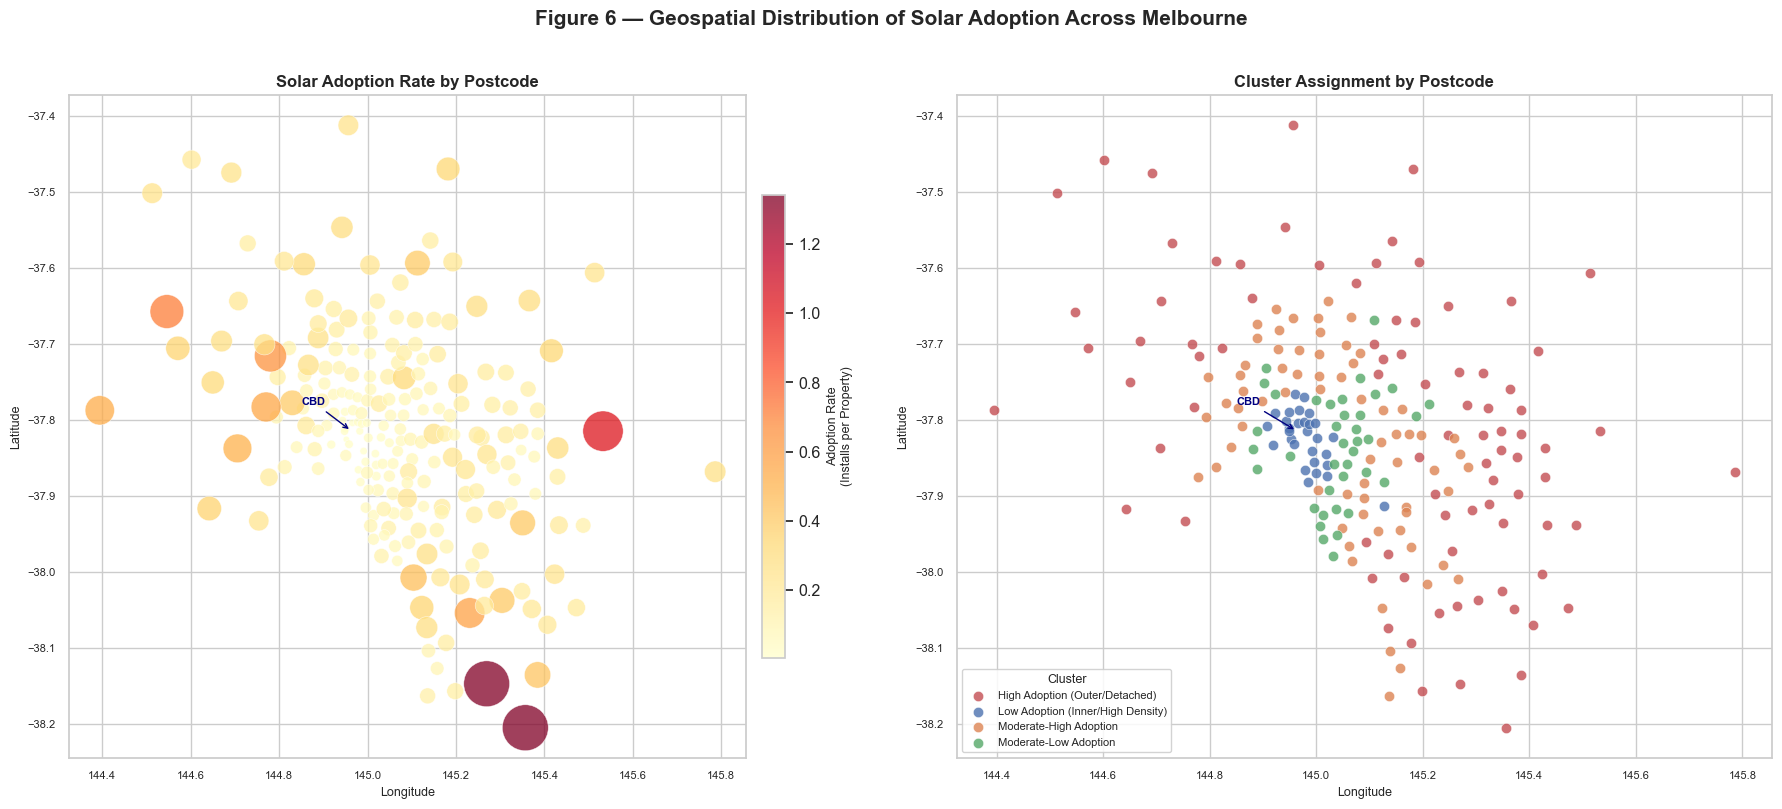

In [7]:
fig6, (ax_adopt, ax_cluster) = plt.subplots(1, 2, figsize=(18, 8))
fig6.suptitle("Figure 6 — Geospatial Distribution of Solar Adoption Across Melbourne", fontsize=15, fontweight="bold", y=1.01)
geo_df = cluster_df.dropna(subset=["lat", "long"]).copy()

# Left: Adoption rate bubble map
sc = ax_adopt.scatter( geo_df["long"], geo_df["lat"], c=geo_df["Adoption_Rate"], s=geo_df["Adoption_Rate"] * 800 + 20, cmap="YlOrRd", alpha=0.75, edgecolors="white",                           linewidth=0.4)
cbar = fig6.colorbar(sc, ax=ax_adopt, shrink=0.7, pad=0.02)
cbar.set_label("Adoption Rate\n(Installs per Property)", fontsize=9)
ax_adopt.set_title("Solar Adoption Rate by Postcode", fontsize=12, fontweight="bold")
ax_adopt.set_xlabel("Longitude", fontsize=9)
ax_adopt.set_ylabel("Latitude", fontsize=9)
ax_adopt.tick_params(labelsize=8)

ax_adopt.annotate("CBD", xy=(144.963, -37.814), fontsize=8, color="navy", fontweight="bold", xytext=(144.85, -37.78),arrowprops=dict(arrowstyle="->", color="navy", lw=1))

# Right: Cluster assignment map
cluster_colors = {
    "Low Adoption\n(Inner/High Density)": "#4C72B0",
    "Moderate-Low\nAdoption":             "#55A868",
    "Moderate-High\nAdoption":            "#DD8452",
    "High Adoption\n(Outer/Detached)":    "#C44E52",
}
for label, grp in geo_df.groupby("Cluster_Label"):
    ax_cluster.scatter( grp["long"], grp["lat"], label=label.replace("\n", " "), color=cluster_colors.get(label, "grey"), s=55, alpha=0.8, edgecolors="white",                              linewidth=0.4)

ax_cluster.set_title("Cluster Assignment by Postcode", fontsize=12, fontweight="bold")
ax_cluster.set_xlabel("Longitude", fontsize=9)
ax_cluster.set_ylabel("Latitude", fontsize=9)
ax_cluster.tick_params(labelsize=8)
ax_cluster.legend(title="Cluster", fontsize=8, title_fontsize=9, loc="lower left", framealpha=0.85)
ax_cluster.annotate("CBD", xy=(144.963, -37.814), fontsize=8, color="navy", fontweight="bold", xytext=(144.85, -37.78), arrowprops=dict(arrowstyle="->", color="navy",                      lw=1))

fig6.tight_layout()

### Data Analytics - Significance Test

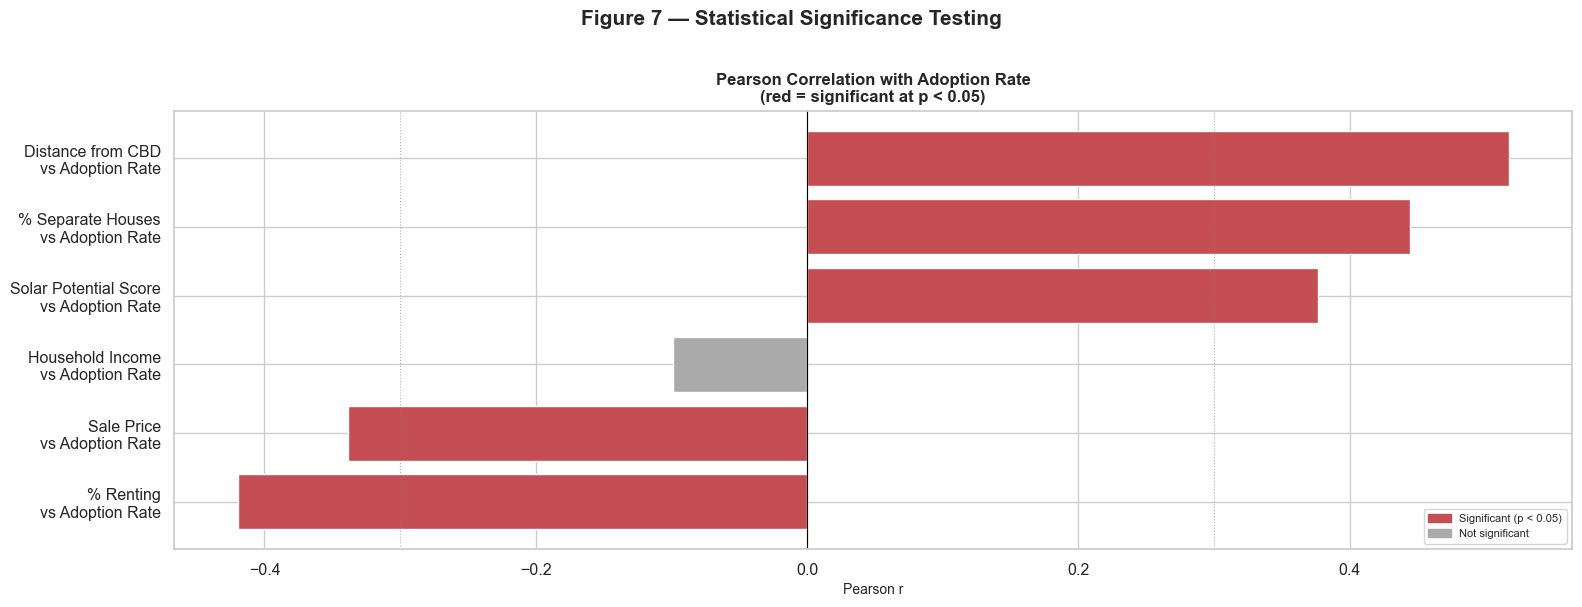

In [8]:
fig7, (ax_corr) = plt.subplots(1, figsize=(16, 6))
fig7.suptitle("Figure 7 — Statistical Significance Testing", fontsize=15, fontweight="bold", y=1.01)

test_pairs = {"% Separate Houses\nvs Adoption Rate": ("Pct_Separate_House", "Adoption_Rate"),
    "% Renting\nvs Adoption Rate": ("Pct_Renting", "Adoption_Rate"),
    "Household Income\nvs Adoption Rate": ("Median_tot_hhd_inc_weekly", "Adoption_Rate"),
    "Sale Price\nvs Adoption Rate": ("Median_Sale_Price", "Adoption_Rate"),
    "Distance from CBD\nvs Adoption Rate": ("Median_Distance", "Adoption_Rate"),
    "Solar Potential Score\nvs Adoption Rate": ("Solar_Potential_Score", "Adoption_Rate"),
}

corr_results = []
for label, (x_col, y_col) in test_pairs.items():
    clean = cluster_df[[x_col, y_col]].dropna()
    r, p = stats.pearsonr(clean[x_col], clean[y_col])
    corr_results.append({ "Pair": label, "r": r, "p_value": p, "Significant": "Yes" if p < 0.05 else "No"})

corr_df = pd.DataFrame(corr_results).sort_values("r")
colors = ["#C44E52" if sig == "Yes" else "#AAAAAA" for sig in corr_df["Significant"]]

bars = ax_corr.barh(corr_df["Pair"], corr_df["r"], color=colors)
ax_corr.axvline(x=0, color="black", linewidth=0.8)
ax_corr.axvline(x=0.3,  color="grey", linewidth=0.8, linestyle=":", alpha=0.6)
ax_corr.axvline(x=-0.3, color="grey", linewidth=0.8, linestyle=":", alpha=0.6)
ax_corr.set_title("Pearson Correlation with Adoption Rate\n(red = significant at p < 0.05)", fontsize=12, fontweight="bold")
ax_corr.set_xlabel("Pearson r", fontsize=10)

sig_patch = mpatches.Patch(color="#C44E52", label="Significant (p < 0.05)")
insig_patch = mpatches.Patch(color="#AAAAAA", label="Not significant")
ax_corr.legend(handles=[sig_patch, insig_patch], fontsize=8, loc="lower right")

fig7.tight_layout()


* Five out of six correlations are statiscally significant at p < 0.001. The most important finding is that household income is not significantly correlated with adoption (r = -0.099, p = 0.146), meaning it is the distance and dwelling type that drive adoption, not wealth. Sale price is negatively correalted (r = -0.338) because expensive inner suburbs have low adoption due to apartments, not because wealthy peoplw avoid solar.

## Discussion

---

### Geographic Patterns of Solar Adoption

The most consistent finding across every analytical method applied is that solar adoption in Melbourne follows a clear and statistically geographic gradient from the CBD outward.

This geographic pattern has a structural explanation, that is inner-city residents are not less interested in solar, they are simply less able to install it, due to a higher apartment living and shared rooftop ownership.

### Income Does Not Drive Adoption - Tenure Does

One of the most policy-relevant findings is what the significance testing did not find. Median household income showed no statistically significant correlation with solar adoption rate. This challenges the intuitive assumption that soar is a wealthy household behaviour.

What does drive adoption is housing tenure. The percentage of renting households was strongly and negatively correlated with adoption. Renters cannot install solar regardless of their income level, since the decision rests with the landlord, who has no financial incentive to invest in solar since energy bills are paid by the tenant.

The negative correlation between sale price and adoption rate is also explained by the same mechanism. The most expensive postcodes in Melbourne are inner-city areas dominated by apartments, and high price does not mean high ownership eligibility.

### Clusters and PCA Segmentation

The four K-Means clusters identified represent four distinct Melbourne suburb types:

* **Cluster 1: Low Adoption, Inner/High Density**:
    * Concentrated in the inner 5km ring.
    * Very high apartment density (82% non-separate housing), very high rental rates (70%), and low solar uptake despite high household incomes.
    * The adoption barrier here is entirely structural.


* **Cluster 2: Moderate-Low Adoption**:
    * The transition zone between the CBD and middle suburbs.
    * High Income, mixed dwelling types (68% separate houses), and moderate renting (43%).
    * The dwelling stock here is largely eligible but adoption rates remain below what housing type would predict.


* **Cluster 3: Moderate-High Adoption**:
    * The established middle suburbs(15-25 Km from CBD).
    * Lower median income when compared to inner suburbs, but good separate housing proportion (73%), and moderate renting (49%).
    * This is cluster is already on a high solar adoption path.


* **Cluster 4: High Adoption, Outer/Detached**:
    * The outer and fringe suburbs (beyond 25 Km from CBD).
    * Almost entirely detached housing (94.5%), low rental rates (25%) and moderate income.
    * Highest solar adoption rate

## Recommendation

---

### Differentiate Policy by Cluster, Not by State or Region

The cluster analysis demonstrates that Melbourne is not a single solar market,but in fact four distinct markets with different barriers, potentials and appropriate interventions. ARENA should avoid applying uniform policies across the metropolitan area and instead develop a cluster-aware framework.

### Prioritise Apartment Solution for the Inner Ring

ARENA should focus investment in the inner ring on funding shared solar infrastructure for apartment buildings, advocating for national strata law reform to simplify rooftop solar apporval processes, and supporting virtual new metering models that allow apartment residents to claim a share of building-level solar generation.

### Address Landlord-Tenant Split Incentive

The significance testing confirmed tenure as a major adoption barrier at a scale that subsidies to tenants alone cannot solve. ARENA should advocate for mandatory disclosure of solar status in rental listings, investigate incentive structures that reward landlords directly for solar installation, and support models where tenants benefit from reduced bills without the landlord bearing the cost upfront.

### Data Collection

The current analysis is constrained by the 2016-2018 housing data window, which prevents tracking how adoption has evolved in response to Victoria's Solar Homes Program (launched in 2018) and subsequent policy changes. The ABS Census cycle, that comes out every 5 years is also too infrequent for this purpose. ARENA should commission or advocate for a linked dataset combining annual solar registration data with annual housing characteristic data at postcode level, enabling before and after policies evaluation.

## References

---

### Datasets

* Small-scale capacity and installation postcode data | Clean Energy Regulator. (2025). Cer.gov.au. https://cer.gov.au/markets/reports-and-data/small-scale-installation-postcode-data
* Melbourne Housing Market. (n.d.). Www.kaggle.com. https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market
* Australian Bureau of Statistics. (2021). Census DataPacks | Australian Bureau of Statistics. Www.abs.gov.au. https://www.abs.gov.au/census/find-census-data/datapacks
* Australian Postcodes. (n.d.). Matthew Proctor. Matthew Proctor’s Blog. https://www.matthewproctor.com/australian_postcodes

### Code References

* Pandas data frame merge - Pandas 1.3.4 documentation. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
* Pandas data frame GroupBy.Aggregate — Pandas 2.2.3 documentation. (2024). Pydata.org. https://pandas.pydata.org/pandas-docs/version/2.2/reference/api/pandas.core.groupby.DataFrameGroupBy.aggregate.html
* MatPlotLib. (n.d.). Matplotlib Pyplot Bar — Matplotlib 3.4.3 documentation. Matplotlib.org. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
* Seaborn regplot — seaborn 0.11.1 documentation. (n.d.). Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.regplot.html
* GeeksforGeeks. (2019, June 6). Elbow Method for optimal value of k in KMeans. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/
* Sil function - RDocumentation. (2022). Rdocumentation.org. https://www.rdocumentation.org/packages/kmed/versions/0.4.2/topics/sil
* Matplotlib Pyplot Annotate — Matplotlib 3.1.2 documentation. (2018). Matplotlib.org. https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.annotate.html
* GeeksforGeeks. (2020, December 9). Seaborn Bubble Plot. GeeksforGeeks. https://www.geeksforgeeks.org/python/seaborn-bubble-plot/
* GeeksforGeeks. (2022, March 26). SciPy Statistical Significance Tests. GeeksforGeeks. https://www.geeksforgeeks.org/python/scipy-statistical-significance-tests/

### External Citations

* Australian Government - Bureau of Communications, Arts and Regional Research. (n.d.). https://www.infrastructure.gov.au/sites/default/files/documents/bcarr-ring-classification-for-5-largest-capital-cities-in-2021-march-2025.pdf
* jecksom. (2023, April 11). Clustering and Principal Component Analysis (PCA) from Sklearn. Medium. https://medium.com/@jackiee.jecksom/clustering-and-principal-component-analysis-pca-from-sklearn-c8ea5fed6648
* IBM. (2023, December 8). What is principal component analysis (PCA)? Ibm.com. https://www.ibm.com/think/topics/principal-component-analysis
* Holtz, Y. (2024). Bubble Map | Python Graph Gallery. The Python Graph Gallery. https://python-graph-gallery.com/bubble-map/
* Abdishakur. (2020, April 20). How to create bubble maps in Python with Geospatial data | Towards Data Science. Towards Data Science. https://towardsdatascience.com/how-to-create-bubble-maps-in-python-with-geospatial-data-e51118c3d767/
* Solar Homes Program | Solar Victoria. (n.d.). Www.solar.vic.gov.au. https://www.solar.vic.gov.au/solar-homes-program
* Solar Homes Program reporting | Solar Victoria. (n.d.). Www.solar.vic.gov.au. https://www.solar.vic.gov.au/solar-homes-program-reporting
* Solar for Apartments extended to help more Victorians save on energy bills. (2026, April 30). Vic.gov.au. https://www.solar.vic.gov.au/solar-apartments-extended-help-more-victorians-save-energy-bills
* Solar for rentals and multi-occupancy properties | energy.gov.au. (2024). Energy.gov.au. https://www.energy.gov.au/solar/switch-solar-power/solar-households/solar-rentals-and-multi-occupancy-properties
* Chandran, R. (n.d.). Australia’s push to put more solar panels on rental homes | Context. Www.context.news. https://www.context.news/just-transition/australias-push-to-put-more-solar-panels-on-rental-homes